## Classification

In [ ]:
# import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap


from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

# classifiers
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC


### Data loading

In [ ]:
df=pd.read_csv('/content/employee_shortlisting.csv')  #add path employee_shortlisting.csv


In [ ]:
df.head()

,Interview_Score,Skills_Matched,Shortlisted
0,8.730597,3.245203,Yes
1,6.070919,2.105576,No
2,8.254656,2.682729,Yes
3,6.136732,2.777711,No
4,8.785921,3.233440,Yes


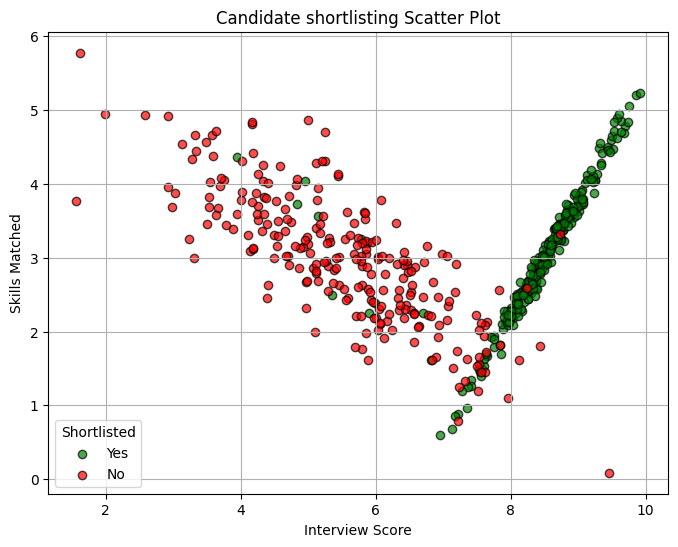

In [ ]:
# scatterplot
plt.figure(figsize=(8,6))
colors={'Yes':'green','No':'red'}

for label in df['Shortlisted'].unique():
  subset=df[df['Shortlisted']==label]
  plt.scatter(subset['Interview_Score'],subset['Skills_Matched'],
              c=colors[label], label=label, alpha=0.7,edgecolors='k')

plt.title("Candidate shortlisting Scatter Plot")
plt.xlabel("Interview Score")
plt.ylabel("Skills Matched")
plt.legend(title='Shortlisted')
plt.grid(True)
plt.show()

## Model Building

In [ ]:
# Features and target
df['Shortlisted']=df['Shortlisted'].map({'Yes':1,'No':0})
X=df[['Interview_Score','Skills_Matched']].values.astype(float)
y=df['Shortlisted'].values.astype(float)

In [ ]:
# Split Data

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
# Define Classifiers
# tweek the parameters for better accuracy
models={
    'Logistic Regression':LogisticRegression(),
    'Decision Tree':DecisionTreeClassifier(max_depth=9, min_samples_split=20,random_state=42),
    'Random Forest':RandomForestClassifier(max_depth=5, random_state=42),
    'KNN':KNeighborsClassifier(n_neighbors=3), # tweek n_neighbors score for better accuracy
    'SVC':SVC(kernel='linear')

}

for name, model in models.items():
  model.fit(X_train,y_train)
  y_pred=model.predict(X_test)
  print(name, 'Accuracy Score', round(accuracy_score(y_test, y_pred),2))



Logistic Regression Accuracy Score 0.9
Decision Tree Accuracy Score 0.94
Random Forest Accuracy Score 0.93
KNN Accuracy Score 0.95
SVC Accuracy Score 0.89


Logistic Regression Accuracy Score 0.9
Decision Tree Accuracy Score 0.94
Random Forest Accuracy Score 0.93
KNN Accuracy Score 0.95
SVC Accuracy Score 0.89


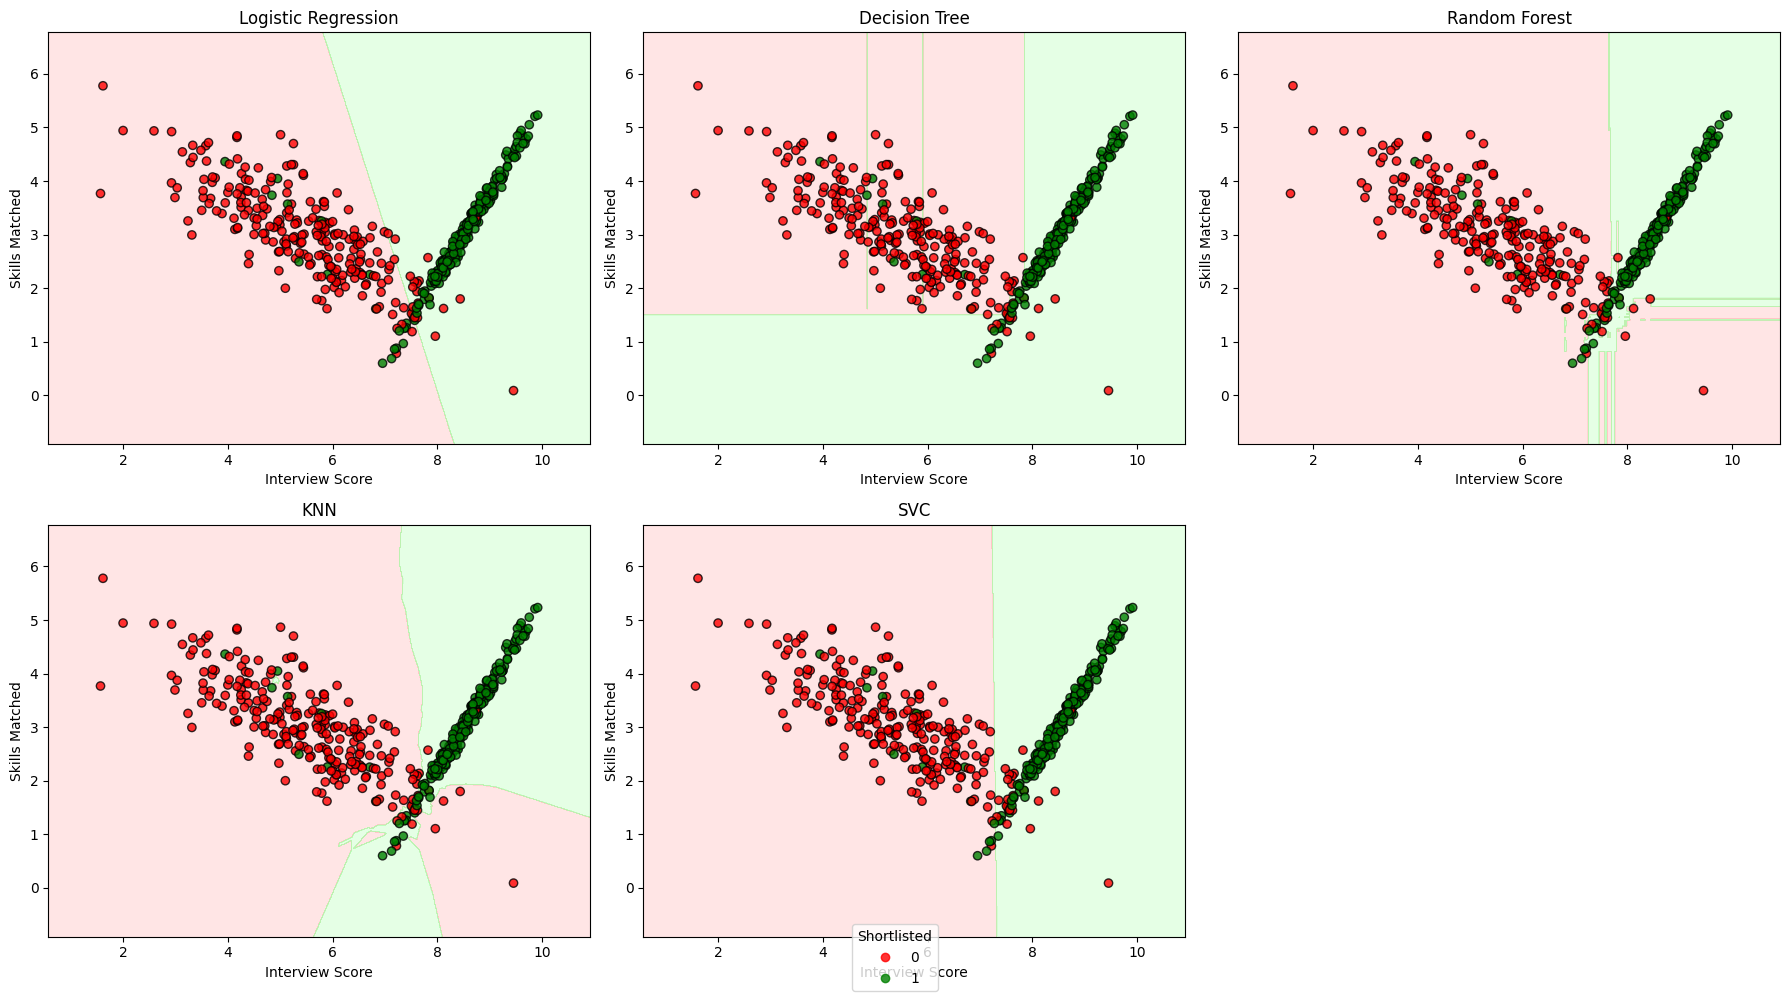

In [ ]:

# create mesh grid for plotting
x_min, x_max =X[:,0].min()-1, X[:,0].max()+1
y_min, y_max =X[:,1].min()-1, X[:,1].max()+1

xx,yy=np.meshgrid(np.arange(x_min,x_max,0.01),
                  np.arange(y_min,y_max,0.01))


# plot decision boundaries

fig,axes=plt.subplots(2,3,figsize=(18,10))
axes=axes.ravel()
cmap_light=ListedColormap(['#FFAAAA','#AAFFAA'])
cmap_bold=['red','green']


for idx, (name,model) in enumerate(models.items()):
  model.fit(X_train,y_train)
  y_pred=model.predict(X_test)
  print(name, 'Accuracy Score', round(accuracy_score(y_test, y_pred),2))
  Z=model.predict(np.c_[xx.ravel(),yy.ravel()])
  Z=Z.reshape(xx.shape)

  axes[idx].contourf(xx,yy,Z,alpha=0.3, cmap=cmap_light)
  scatter=axes[idx].scatter(X[:,0],X[:,1],c=y,cmap=ListedColormap(cmap_bold),edgecolors='k',alpha=0.8)
  axes[idx].set_title(name)
  axes[idx].set_xlabel('Interview Score')
  axes[idx].set_ylabel('Skills Matched')

# Hide unused subplot
fig.delaxes(axes[-1])

# add legend
fig.legend(*scatter.legend_elements(),loc='lower center',title='Shortlisted')

plt.tight_layout()
plt.show()


## Regression models

In [43]:
# Regression models
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR
from sklearn.metrics import r2_score

import matplotlib.pyplot as plt
import seaborn as sns


In [ ]:
df =pd.read_csv('/content/marketing_spend.csv')

In [ ]:
df.head()

,Date,Marketing_Spend_1000s,Employee_Count,Product_Rating,Customer_Acquisition_Cost,Quarterly_Revenue,Annual_Revenue,Customer_Lifetime_Value
0,2024-01-01,43.708611,18.250200,7.283455,1910.442649,265.106375,273.074702,354.029924
1,2024-01-02,95.564288,22.329398,5.824867,9132.533060,687.783503,567.896906,1012.873825
2,2024-01-03,75.879455,43.301150,3.785749,5757.691655,518.959402,520.257186,800.570271
3,2024-01-04,63.879264,19.261490,8.324155,4080.560315,378.920094,389.676220,577.055925
4,2024-01-05,24.041678,12.627174,7.162581,578.002264,169.671985,178.742889,193.317841


In [ ]:
# selecting features and target variable
X=df[['Marketing_Spend_1000s', 'Employee_Count','Product_Rating']]  # Indepenent variables
y=df['Quarterly_Revenue'] # Dependent variable


In [ ]:
# train test split
X_train, X_test, y_train,y_test=train_test_split(X,y, test_size=0.2, random_state=42)

In [ ]:
# define classifiers

models={
    'KNN':KNeighborsRegressor(n_neighbors=10),
    'Decision Tree':DecisionTreeRegressor(max_depth=3, random_state=42),
    'Random Forest':RandomForestRegressor(max_depth=4, random_state=42),
    'SVR':SVR(kernel='linear')
}

for name, model in models.items():
  model.fit(X_train,y_train)
  y_pred=model.predict(X_test)
  print(name, 'Accuracy Score',round(r2_score(y_test, y_pred),2))

KNN Accuracy Score 0.93
Decision Tree Accuracy Score 0.86
Random Forest Accuracy Score 0.91
SVR Accuracy Score 0.94


### Visualizing Regression Model Predictions

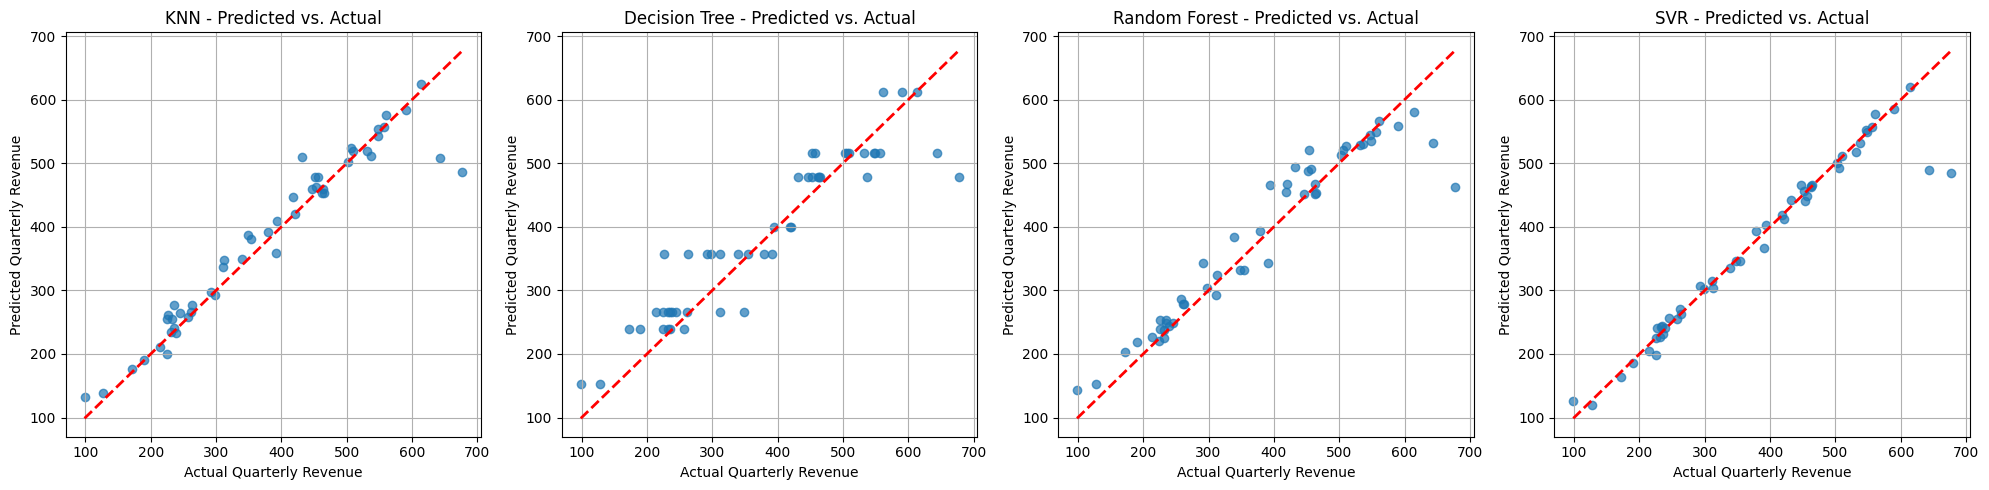

In [42]:
fig, axes = plt.subplots(1, len(models), figsize=(5 * len(models), 5))
axes = axes.flatten()

for i, (name, model) in enumerate(models.items()):
    model.fit(X_train, y_train) # Re-fit the model
    y_pred = model.predict(X_test)

    ax = axes[i]
    ax.scatter(y_test, y_pred, alpha=0.7)
    ax.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2) # Ideal prediction line
    ax.set_title(f'{name} - Predicted vs. Actual')
    ax.set_xlabel('Actual Quarterly Revenue')
    ax.set_ylabel('Predicted Quarterly Revenue')
    ax.grid(True)

plt.tight_layout()
plt.show()

From the generated visualizations and the R2 scores, the SVR (Support Vector Regressor) model appears to be the best performing. It achieved the highest R2 score of 0.94, and visually, its scattered points on the 'Predicted vs. Actual' plot are most tightly clustered around the red dashed ideal prediction line. KNN also performed very well with an R2 score of 0.93.

